<a href="https://colab.research.google.com/github/anaruizn/Paralelizacion/blob/main/Trabajo_3__Computaci%C3%B3n_Avanzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='Blue'>**Tarea computacional #3: Proyecto paralelización**</font>

## *Presentado por:*
## <font color='magenta'>**Ana Luz Ruiz Noriega**</font>

In [16]:
#Importamos las librerías
import numpy as np
import pandas as pd
import time
import multiprocessing as mp

# Definimos las constantes
h = 6.626e-34  # Constante de Planck (J·s)
c = 3.0e8       # Velocidad de la luz (m/s)
k_B = 1.38e-23  # Constante de Boltzmann (J/K)
eV_to_J = 1.602e-19  # Conversión de eV a J
E_F = 5.5 * eV_to_J  # Energía de Fermi típica (en J)

# Definimos la función de distribución de Fermi-Dirac para establecer la distribución de los electrones.
def fermi_dirac(E, T):
    return 1 / (np.exp((E - E_F) / (k_B * T)) + 1)

def funcion_1atomo(frecuencias, phi , T = 300 , n_iter = 100000): # Función para el caso de 1 átomo

    energias_foton = h * frecuencias / eV_to_J  # Energías en eV
    phi_J = phi * eV_to_J  # Convierte la función de trabajo de eV a Joules

    electrones_emitidos = np.zeros_like(energias_foton)  # Almacenará el número de emisiones generados por cada energía
    fotones_reflejados = np.zeros_like(energias_foton)   # Almacenará el número de fotones reflejados por cada energía
    fotones_transmitidos = np.zeros_like(energias_foton) # Almacenará el número de fotones transmitidos por cada energía

    tiempos = np.zeros_like(energias_foton)

    for i, E_foton in enumerate(energias_foton):   # Recorre todas las energías de los fotones

            tiempo_inicial = time.time()  # Cuenta el tiempo para las n_iter iteraciones

            for _ in range(n_iter):    # Se ejecuta el algoritmo n_iter veces para cada energía de fotón.
                E_electron = np.random.uniform(0, E_F)  # Genera una energía aleatoria dentro del rango [0, E_F]
                P = fermi_dirac(E_electron, T)    # Calcula la probabilidad de ocupación de un estado con energía E_electrón

                if np.random.rand() < P:          # Se genera un número aleatorio entre 0 y 1.
                    if (E_foton * eV_to_J + E_electron > phi_J):  # Verifica si la energía total es mayor que la función de trabajo
                        electrones_emitidos[i] += 1  # Si es mayor, se emite un electrón
                    else:
                        fotones_reflejados[i] += 1
                else:
                    fotones_transmitidos[i] += 1

            tiempo_final = time.time()

            tiempos[i] = tiempo_final - tiempo_inicial

    return tiempos, energias_foton, electrones_emitidos / n_iter, fotones_reflejados / n_iter, fotones_transmitidos / n_iter

def funcion_3atomos (frecuencias, metal_props , T = 300 , n_iter = 100000):    # Función para el caso de 3 átomos

    phi = metal_props["phi"] # Asigna el valor de la función de trabajo para cada metal
    D = metal_props["D"]  # Asigna el valor del diámetro para cada metal
    S = metal_props["S"]  # Asigna el valor de la distancia entre átomos para cada metal
    L = 4 * S + 3 * D     # Tamaño de la red en 1D con la disposición [SDSDSDS]

    energias_foton = h * frecuencias / eV_to_J  # Energías en eV
    phi_J = phi * eV_to_J  # Convierte la función de trabajo de eV a Joules

    electrones_emitidos = np.zeros_like(energias_foton)  # Almacenará la cantidad de electrones emitidos para cada energía de fotón
    fotones_reflejados = np.zeros_like(energias_foton)   # Almacenerá la cantidad de fotones reflejados para cada energía
    fotones_transmitidos = np.zeros_like(energias_foton) # Almacenerá la cantidad de fotones transmitidos para cada energía

    interactuaron = np.zeros_like(energias_foton)  # Contará cuántos fotones interactuaron con el material
    no_interactuaron = np.zeros_like(energias_foton)  # Contará cuántos fotones no interactuaron con el material

    tiempos = np.zeros_like(energias_foton)

    for i, E_foton in enumerate(energias_foton):  # Recorre todas las energías de los fotones

        tiempo_inicial = time.time()     # Cuenta el tiempo para las n_iter iteraciones

        for _ in range(n_iter):  # Se ejecuta el algoritmo n_iter veces para cada energía de fotón.
            pos_foton = np.random.uniform(0, L)  # Genera una posición aleatoria para el fotón dentro del rango [0, L]
            E_electron = np.random.uniform(0, E_F)  # Genera una energía aleatoria para el electrón en el rango [0, E_F]
            P = fermi_dirac(E_electron, T)  #  Calcula la probabilidad de ocupación de los estados electrónicos para un electrón.

            # Verificamos si el fotón interactúa con algún átomo respetando el arreglo [SDSDSDS]
            interaccion = False       # Si el fotón no interactúa con el átomo
            for j in range(3):
                x0 = S + j * (S + D)  # Calcula el inicio del intervalo del átomo
                if x0 <= pos_foton <= x0 + D:  # Verifica si la posición del fotón está dentro del intervalo del átomo
                    interaccion = True    # Si el fotón interactúa con el átomo
                    break

            # Determinamos el tipo de interacción
            if interaccion:
                interactuaron[i] += 1

                if np.random.rand() < P:
                    # Verificamos si tiene energía suficiente para emitir un electrón
                    if (E_foton * eV_to_J + E_electron > phi_J):
                        electrones_emitidos[i] += 1  # electrón emitido
                    else:
                        fotones_reflejados[i] += 1  # no tiene suficiente energía, se considera reflejado
                else:
                    fotones_transmitidos[i] += 1 # Si no hay ocupación, se transmite
            else:
                no_interactuaron[i] += 1
                fotones_transmitidos[i] += 1

        tiempo_final = time.time()

        tiempos[i] = tiempo_final - tiempo_inicial

    return tiempos, energias_foton, electrones_emitidos / n_iter, fotones_reflejados / n_iter, fotones_transmitidos / n_iter , interactuaron / n_iter, no_interactuaron / n_iter

# Definimos los valores de la función de trabajo en eV para cada metal, diámetro atómico D (en metros) y separación interatómica (en metros)
metales = {
    "Aluminio": {"phi": 4.28, "D": 2*1.43e-10, "S": 2.86e-10},
    "Cobre": {"phi": 4.7, "D": 2*1.28e-10, "S": 2.55e-10},
    "Oro": {"phi": 5.1, "D": 2*1.44e-10, "S": 2.88e-10},
    "Plata": {"phi": 4.73, "D": 2*1.45e-10, "S": 2.90e-10},
    "Hierro": {"phi": 4.5, "D": 2*1.26e-10, "S": 2.52e-10}
}

frecuencias = np.linspace(2e14, 1e15, 100)  # Frecuencias en Hz para todos los análisis

# Análisis para 1 átomo
print("\nAnálisis computación en serie:\n")

print("\nComienza el análisis para 1 átomo y todos los metales\n")

# Itera directamente sobre el diccionario de metales
for nombre, props in metales.items():
    resultados = funcion_1atomo(frecuencias=frecuencias, phi=props["phi"], n_iter=100000)
    tiempos, energias, emitidos, reflejados, transmitidos = resultados

    df = pd.DataFrame({ "frecuencia (Hz)": frecuencias, "energia_foton (eV)": energias, "electrones_emitidos": emitidos, "fotones_reflejados": reflejados, "fotones_transmitidos": transmitidos, "tiempo_ejecucion (s)": tiempos})

    # Guardar como CSV
    df.to_csv(f"resultados_1atomo_{nombre}.csv", index=False)

print("\nFinaliza el análisis para 1 átomo y todos los metales\n")

# analisis para 1 atomo
print("\nComienza el análisis para 3 átomos y todos los metales\n")

# Iterar directamente sobre el diccionario de metales
for nombre, props in metales.items():
    resultados = funcion_3atomos(frecuencias=frecuencias, metal_props = props , n_iter=100000)
    tiempos, energias, emitidos, reflejados, transmitidos, interactuaron, no_interactuaron = resultados

    df = pd.DataFrame({ "frecuencia (Hz)": frecuencias, "energia_foton (eV)": energias, "electrones_emitidos": emitidos, "fotones_reflejados": reflejados, "fotones_transmitidos": transmitidos,
                       "fotones_interactuaron": interactuaron, "fotones_no_interactuaron": no_interactuaron, "tiempo_ejecucion (s)": tiempos})

    # Guardar como CSV
    df.to_csv(f"resultados_3atomos_{nombre}.csv", index=False)

print("\nFinaliza el análisis para 3 átomos y todos los metales\n")

# Empieza paralelización
import os   # permite interactuar con funcionalidades del sistema operativo (como obtener el ID del proceso actual)

numero_procesadores_usar = 2  # Define el número de procesadores que se desea utilizar

def frecuencia_sola_1atomo(frecuencia, metal):
    pid = os.getpid() # Identificador del procesador
    print(f'Procesador {pid} trabajando en la frecuencia {frecuencia} para {metal}, phi = {metales[metal]["phi"]}')
    tiempos, energias, emitidos, reflejados, transmitidos = funcion_1atomo(frecuencias = np.array([frecuencia]), phi = metales[metal]["phi"], n_iter = 100000)
    print(f'Procesador {pid} finalizó la frecuencia {frecuencia} para {metal}, phi = {metales[metal]["phi"]}')

    return tiempos, energias, emitidos, reflejados, transmitidos

def frecuencia_sola_3atomos(frecuencia, metal):
    tiempos, energias, emitidos, reflejados, transmitidos, interactuaron, no_interactuaron = funcion_3atomos(frecuencias = np.array([frecuencia]), metal_props = metales[metal], n_iter = 100000)
    return tiempos, energias, emitidos, reflejados, transmitidos, interactuaron, no_interactuaron

metales_lista = ["Aluminio", "Cobre", "Oro", "Plata", "Hierro"]

args = [[(f, m) for f in frecuencias]  for m in metales_lista]   # Crea una lista de listas que contiene tuplas (frecuencia, metal) para cada combinación

Tiempos_1atomo_par = np.zeros(5)
Tiempos_1atomo_par_prom = np.zeros(5)
Tiempos_3atomos_par = np.zeros(5)
Tiempos_3atomos_par_prom = np.zeros(5)

print("\nAnálisis de paralelización:\n")

print(f"\nNúmero de núcleos disponibles: {mp.cpu_count()}\n") # muestra el número de procesadores

print(f"\nNúmero de núcleos usados: {numero_procesadores_usar}\n")

print("\nComienza análisis para 1 átomo y todos los metales\n")

for i, metal in enumerate(metales_lista):
    tiempo_inicial = time.time()

    args_metal = args[i]  # Lista de tuplas: [(f1, metal), (f2, metal), ...]

    resultados = []
    with mp.Pool(processes=numero_procesadores_usar) as pool:
        resultados_async = [
            pool.apply_async(frecuencia_sola_1atomo, args=par)
            for par in args_metal
        ]
        resultados = [res.get() for res in resultados_async]

    tiempo_final = time.time()

    Tiempos_1atomo_par[i] = tiempo_final - tiempo_inicial
    Tiempos_1atomo_par_prom[i] = np.mean([r[0] for r in resultados])

    energias = [r[1][0] for r in resultados]
    emitidos = [r[2][0] for r in resultados]
    reflejados = [r[3][0] for r in resultados]
    transmitidos = [r[4][0] for r in resultados]

    df = pd.DataFrame({
        "frecuencia (Hz)": frecuencias,
        "energia_foton (eV)": energias,
        "electrones_emitidos": emitidos,
        "fotones_reflejados": reflejados,
        "fotones_transmitidos": transmitidos
    })

    df.to_csv(f"resultados_1atomo_{metal}_par.csv", index=False)
# Crear un DataFrame con los datos
df = pd.DataFrame({
    'Metales': ['Aluminio', 'Cobre', 'Oro', 'Plata', 'Hierro'],
    'Tiempo total (s)': Tiempos_1atomo_par,
    'Tiempo promedio (s)': Tiempos_1atomo_par_prom})

# Guardar el DataFrame en un archivo CSV
df.to_csv("Tiempos_1atomo_par.csv", index=False)

print("\nFinaliza análisis para 1 átomo y todos los metales\n")

print("\nEmpieza análisis para 3 átomos y todos los metales\n")

for i, metal in enumerate(metales_lista):

    tiempo_inicial = time.time()
    args_metal = args[i]  # Lista de tuplas: [(f1, metal), (f2, metal), ...]

    resultados = []
    with mp.Pool(processes=numero_procesadores_usar) as pool:   # Ejecuta cada simulación de frecuencia en paralelo
        resultados_async = [
            pool.apply_async(frecuencia_sola_3atomos, args=par)
            for par in args_metal
        ]
        resultados = [res.get() for res in resultados_async]    # Espera a que terminen y recolecta los resultados

    tiempo_final = time.time()

    Tiempos_3atomos_par[i] = tiempo_final - tiempo_inicial
    Tiempos_3atomos_par_prom[i] = np.mean([resultado[0] for resultado in resultados])

    energias = [resultado[1][0] for resultado in resultados]      # Extrae los valores de energía, electrones emitidos, etc., para cada frecuencia
    emitidos = [resultado[2][0] for resultado in resultados]
    reflejados = [resultado[3][0] for resultado in resultados]
    transmitidos = [resultado[4][0] for resultado in resultados]
    interactuaron = [resultado[5][0] for resultado in resultados]
    no_interactuaron = [resultado[6][0] for resultado in resultados]

    df = pd.DataFrame({
        "frecuencia (Hz)": frecuencias,
        "energia_foton (eV)": energias,
        "electrones_emitidos": emitidos,
        "fotones_reflejados": reflejados,
        "fotones_transmitidos": transmitidos,
        "fotones_interactuaron": interactuaron,
        "fotones_no_interactuaron": no_interactuaron
    })

    df.to_csv(f"resultados_3atomos_{metal}_par.csv", index=False)

# Crear un DataFrame con los datos
df = pd.DataFrame({
    'Metales': ['Aluminio', 'Cobre', 'Oro', 'Plata', 'Hierro'],
    'Tiempo total (s)': Tiempos_3atomos_par,
    'Tiempo promedio (s)': Tiempos_3atomos_par_prom})

# Guardar el DataFrame en un archivo CSV
df.to_csv("Tiempos_3atomos_par.csv", index=False)

print("\nFinaliza análisis para 3 átomos y todos los metales\n")



Análisis computación en serie:


Comienza el análisis para 1 atomo y todos los metales


Finaliza el análisis para 1 atomo y todos los metales


Comienza el análisis para 3 atomos y todos los metales


Finaliza el análisis para 3 atomos y todos los metales


Análisis de paralelización:


Número de núcleos disponibles: 2


Número de núcleos usados: 2


Empieza análisis para 1 átomo y todos los metales

Procesador 34269 trabajando en la frecuencia 200000000000000.0 para Aluminio, phi = 4.28Procesador 34270 trabajando en la frecuencia 208080808080808.1 para Aluminio, phi = 4.28

Procesador 34269 finalizó la frecuencia 200000000000000.0 para Aluminio, phi = 4.28Procesador 34270 finalizó la frecuencia 208080808080808.1 para Aluminio, phi = 4.28

Procesador 34270 trabajando en la frecuencia 224242424242424.25 para Aluminio, phi = 4.28Procesador 34269 trabajando en la frecuencia 216161616161616.16 para Aluminio, phi = 4.28

Procesador 34270 finalizó la frecuencia 224242424242424.25 para Alum

In [17]:
# programa para visualizar los datos

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Metales = ["Aluminio", "Cobre", "Oro", "Plata", "Hierro"]

# colab
nombres_1atomo = ["resultados_1atomo_Aluminio.csv" , "resultados_1atomo_Cobre.csv" , "resultados_1atomo_Oro.csv" , "resultados_1atomo_Plata.csv" , "resultados_1atomo_Hierro.csv"]
nombres_3atomos = ["resultados_3atomos_Aluminio.csv" , "resultados_3atomos_Cobre.csv" , "resultados_3atomos_Oro.csv" , "resultados_3atomos_Plata.csv" , "resultados_3atomos_Hierro.csv"]
nombres_1atomo_par =  ["resultados_1atomo_Aluminio_par.csv" , "resultados_1atomo_Cobre_par.csv" , "resultados_1atomo_Oro_par.csv" , "resultados_1atomo_Plata_par.csv" , "resultados_1atomo_Hierro_par.csv"]
nombres_3atomos_par = ["resultados_3atomos_Aluminio_par.csv" , "resultados_3atomos_Cobre_par.csv" , "resultados_3atomos_Oro_par.csv" , "resultados_3atomos_Plata_par.csv" , "resultados_3atomos_Hierro_par.csv"]
tiempos_1atomo_par = ["Tiempos_1atomo_par.csv"]
tiempos_3atomos_par = ["Tiempos_3atomos_par.csv"]


# servidor
nombres_1atomo_servidor = ["resultados_1atomo_Aluminio_ser.csv", "resultados_1atomo_Cobre_ser.csv", "resultados_1atomo_Oro_ser.csv", "resultados_1atomo_Plata_ser.csv", "resultados_1atomo_Hierro_ser.csv"]
nombres_3atomos_servidor = ["resultados_3atomos_Aluminio_ser.csv", "resultados_3atomos_Cobre_ser.csv", "resultados_3atomos_Oro_ser.csv", "resultados_3atomos_Plata_ser.csv", "resultados_3atomos_Hierro_ser.csv"]
nombres_1atomo_par_servidor = ["resultados_1atomo_Aluminio_par_ser.csv","resultados_1atomo_Cobre_par_ser.csv","resultados_1atomo_Oro_par_ser.csv","resultados_1atomo_Plata_par_ser.csv","resultados_1atomo_Hierro_par_ser.csv"]
nombres_3atomos_par_servidor = ["resultados_3atomos_Aluminio_par_ser.csv","resultados_3atomos_Cobre_par_ser.csv","resultados_3atomos_Oro_par_ser.csv","resultados_3atomos_Plata_par_ser.csv","resultados_3atomos_Hierro_par_ser.csv"]
tiempos_1atomo_par_servidor = ["Tiempos_1atomo_par_ser.csv"]
tiempos_3atomos_par_servidor = ["Tiempos_3atomos_par_ser.csv"]


# colab
resultados_1atomo = []
resultados_3atomos = []
resultados_1atomo_par = []
resultados_3atomos_par = []
resultados_tiempos_1atomo_par = pd.read_csv(tiempos_1atomo_par[0])
resultados_tiempos_3atomos_par = pd.read_csv(tiempos_3atomos_par[0])

for nombre in nombres_1atomo:
    df = pd.read_csv(nombre)
    resultados_1atomo.append(df)

for nombre in nombres_3atomos:
    df =  pd.read_csv(nombre)
    resultados_3atomos.append(df)

for nombre in nombres_1atomo_par:
    df =  pd.read_csv(nombre)
    resultados_1atomo_par.append(df)

for nombre in nombres_3atomos_par:
    df =  pd.read_csv(nombre)
    resultados_3atomos_par.append(df)

 # servidor
resultados_1atomo_servidor = []
resultados_3atomos_servidor = []
resultados_1atomo_par_servidor = []
resultados_3atomos_par_servidor = []
resultados_tiempos_1atomo_par_servidor = pd.read_csv(tiempos_1atomo_par_servidor[0])
resultados_tiempos_3atomos_par_servidor = pd.read_csv(tiempos_3atomos_par_servidor[0])

for nombre in nombres_1atomo_servidor:
    df = pd.read_csv(nombre)
    resultados_1atomo_servidor.append(df)

for nombre in nombres_3atomos_servidor:
    df =  pd.read_csv(nombre)
    resultados_3atomos_servidor.append(df)

for nombre in nombres_1atomo_par_servidor:
    df =  pd.read_csv(nombre)
    resultados_1atomo_par_servidor.append(df)

for nombre in nombres_3atomos_par_servidor:
    df =  pd.read_csv(nombre)
    resultados_3atomos_par_servidor.append(df)

colores = ['blue', 'orange', 'gold', 'gray', 'brown']  # colores para distinguir

Análisis para colab, computacion en serie

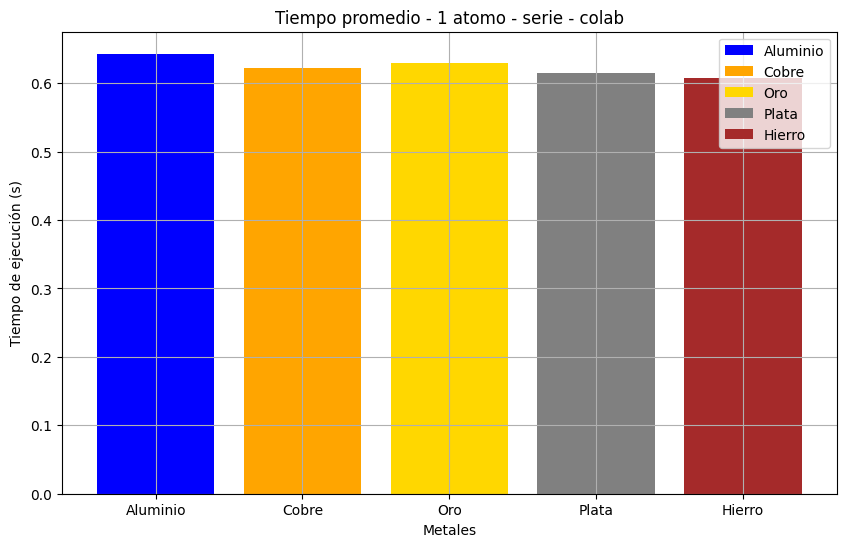

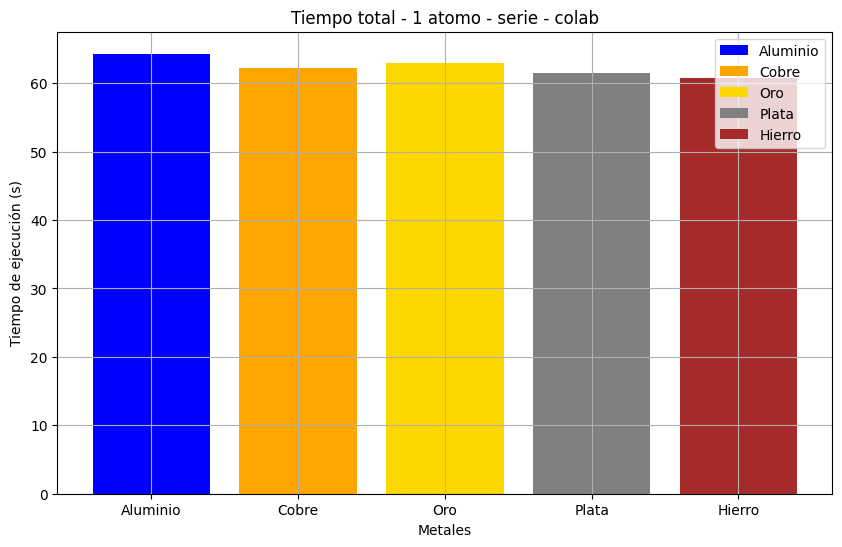

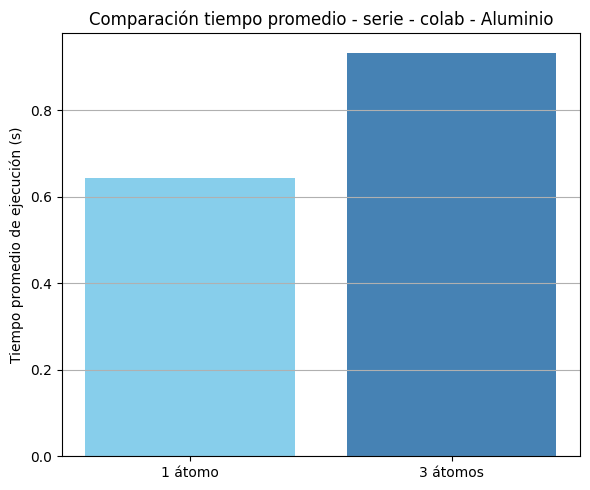

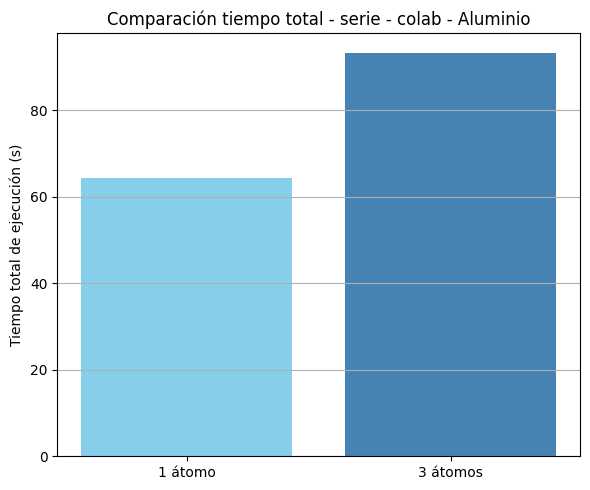

In [18]:
# Análisis para los tiempos
plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo, Metales, colores):
    plt.bar(nombre, df["tiempo_ejecucion (s)"].mean(), label=nombre, color=color)

plt.xlabel("Metales")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo promedio - 1 atomo - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

# Análisis para los tiempos
plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo, Metales, colores):
    plt.bar(nombre, df["tiempo_ejecucion (s)"].sum(), label=nombre, color=color)

plt.xlabel("Metales")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo total - 1 atomo - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de comparación
plt.figure(figsize=(6, 5))
plt.bar(["1 átomo", "3 átomos"], [resultados_1atomo[0]["tiempo_ejecucion (s)"].mean(), resultados_3atomos[0]["tiempo_ejecucion (s)"].mean()], color=["skyblue", "steelblue"])
plt.ylabel("Tiempo promedio de ejecución (s)")
plt.title("Comparación tiempo promedio - serie - colab - Aluminio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Gráfico de comparación
plt.figure(figsize=(6, 5))
plt.bar(["1 átomo", "3 átomos"], [resultados_1atomo[0]["tiempo_ejecucion (s)"].sum(), resultados_3atomos[0]["tiempo_ejecucion (s)"].sum()], color=["skyblue", "steelblue"])
plt.ylabel("Tiempo total de ejecución (s)")
plt.title("Comparación tiempo total - serie - colab - Aluminio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

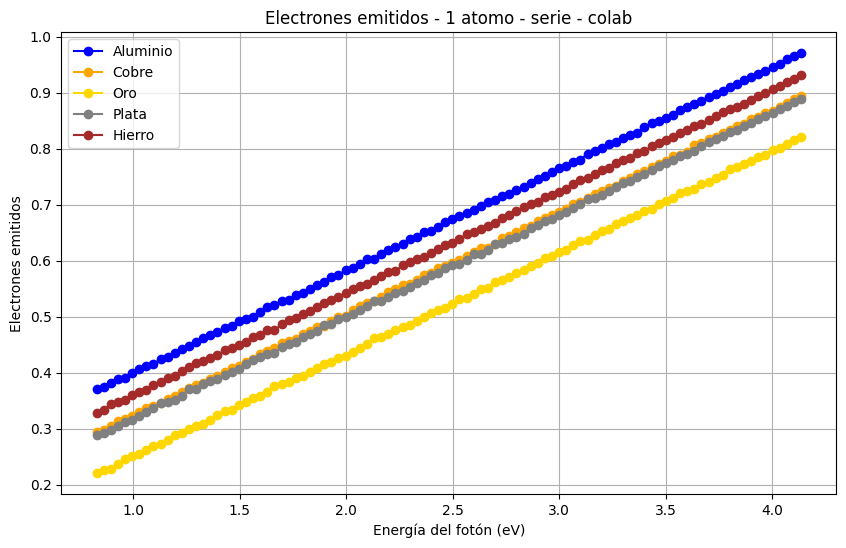

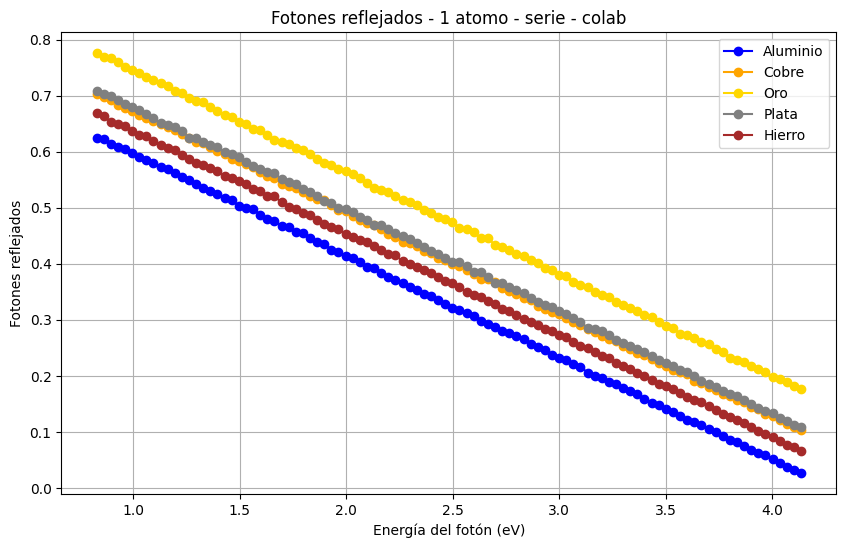

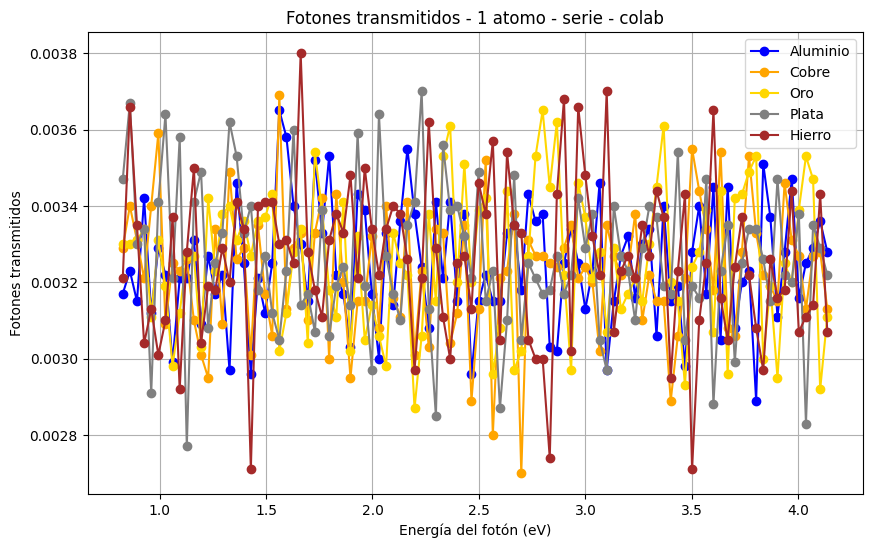

In [19]:
# graficas para el analisis de 1 solo atomo

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["electrones_emitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Electrones emitidos")
plt.title("Electrones emitidos - 1 atomo - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_reflejados"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones reflejados")
plt.title("Fotones reflejados - 1 atomo - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_transmitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones transmitidos")
plt.title("Fotones transmitidos - 1 atomo - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

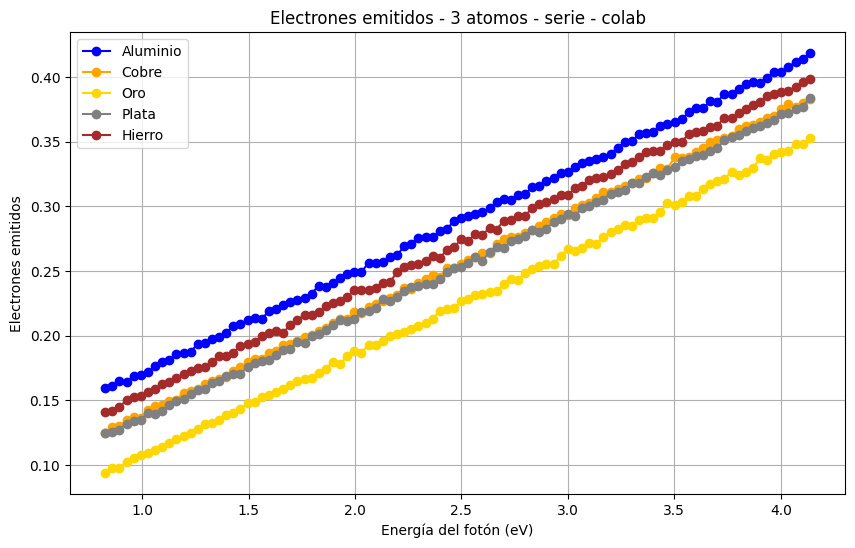

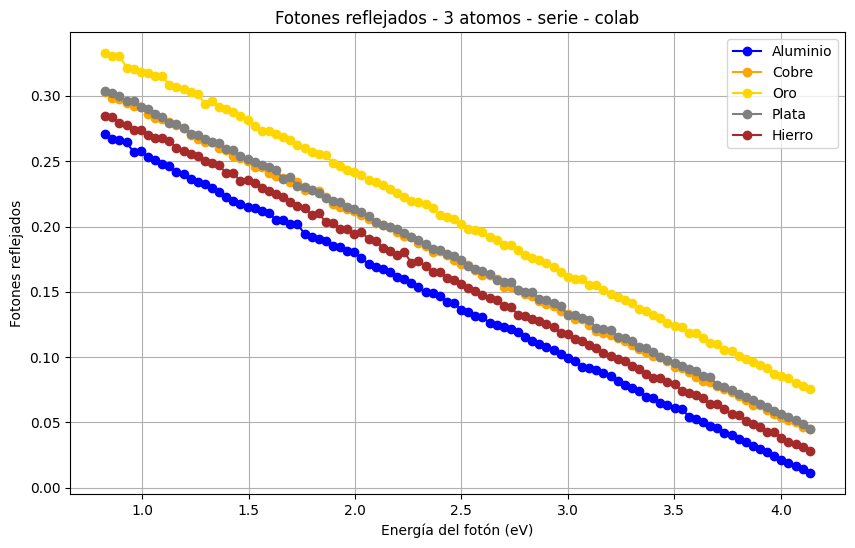

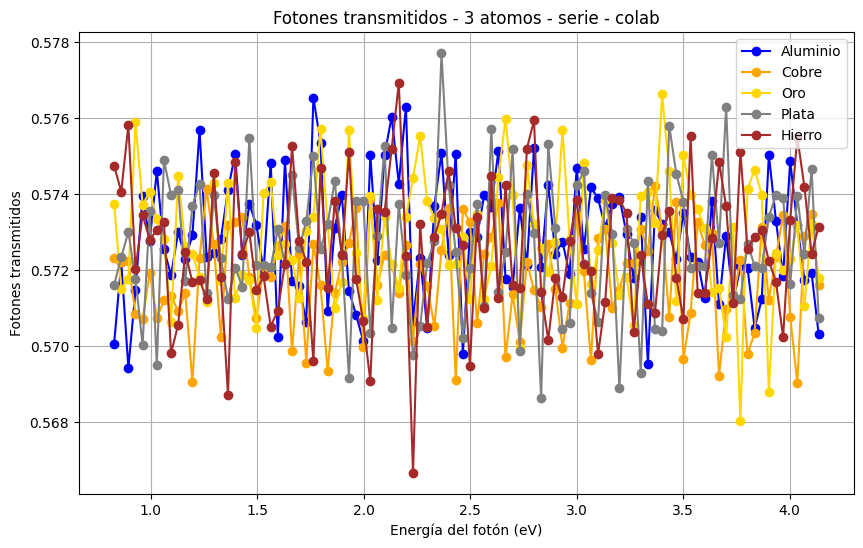

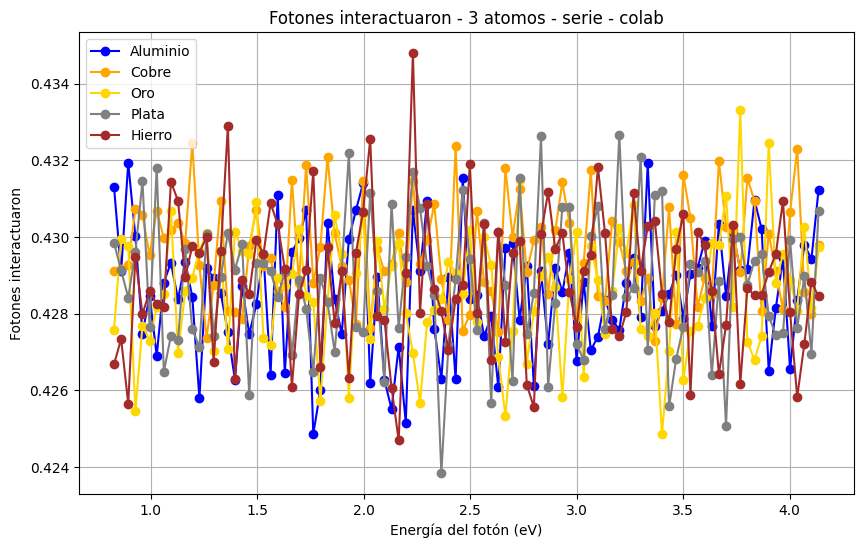

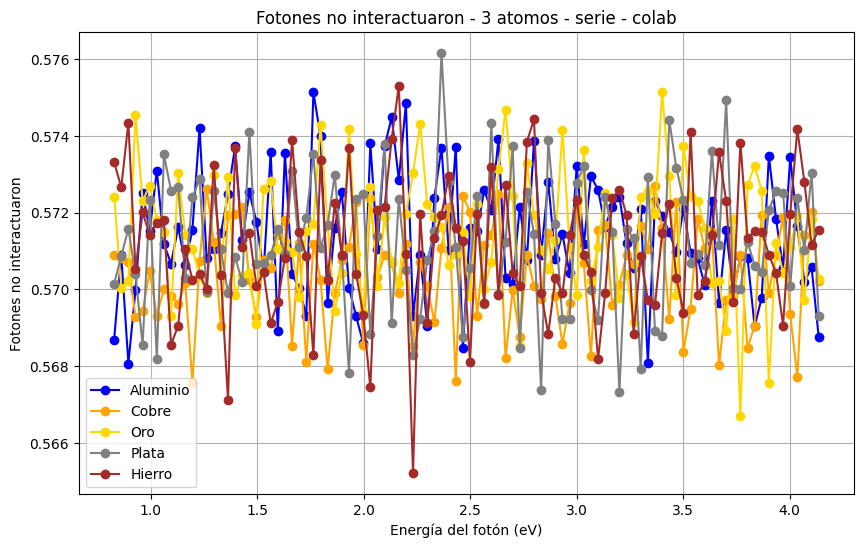

In [20]:
# graficas para los resultados de 3 atomos
plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["electrones_emitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Electrones emitidos")
plt.title("Electrones emitidos - 3 atomos - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_reflejados"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones reflejados")
plt.title("Fotones reflejados - 3 atomos - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_transmitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones transmitidos")
plt.title("Fotones transmitidos - 3 atomos - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_interactuaron"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones interactuaron")
plt.title("Fotones interactuaron - 3 atomos - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_no_interactuaron"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones no interactuaron")
plt.title("Fotones no interactuaron - 3 atomos - serie - colab")
plt.legend()
plt.grid(True)
plt.show()

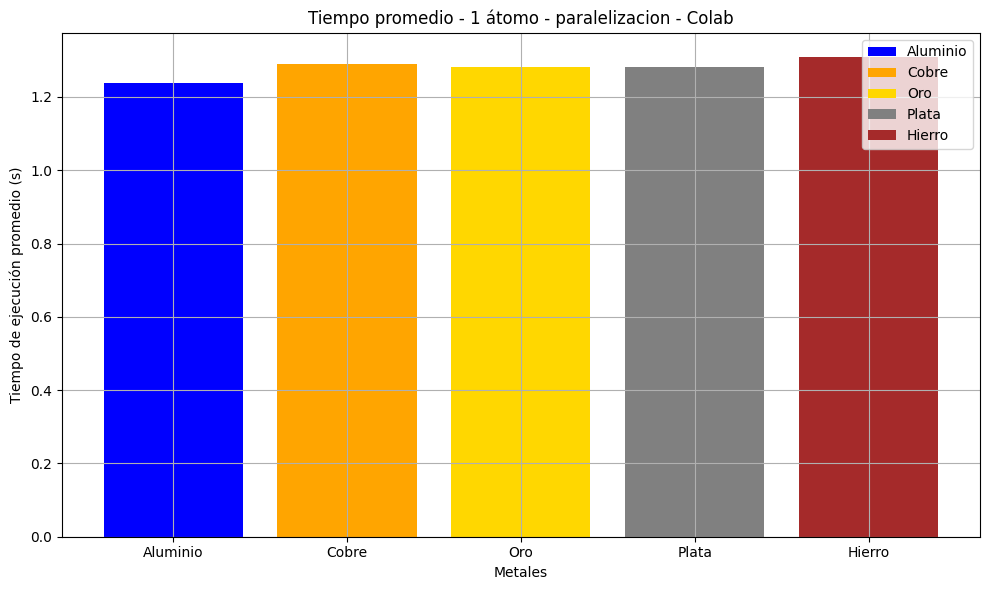

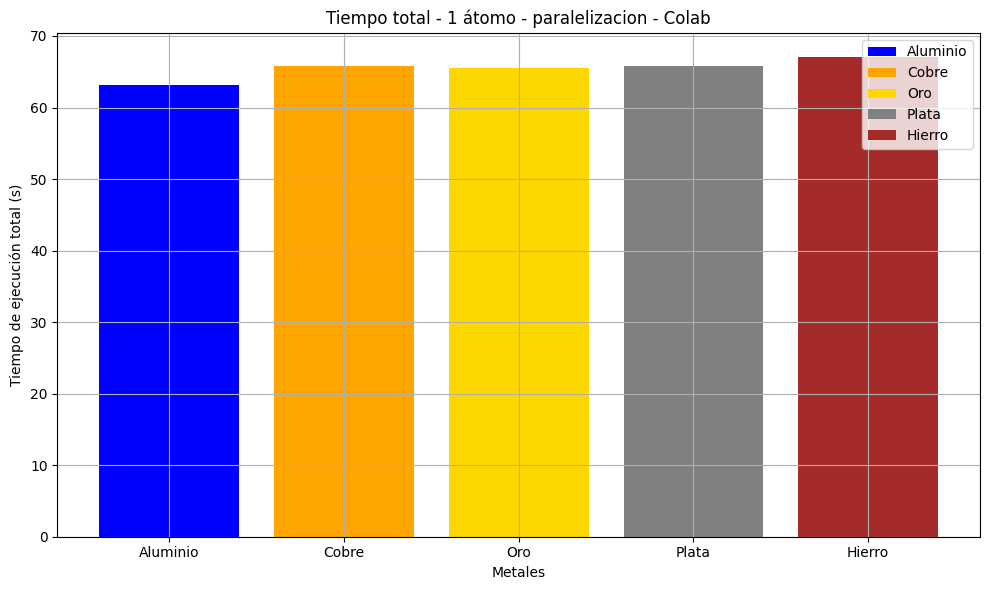

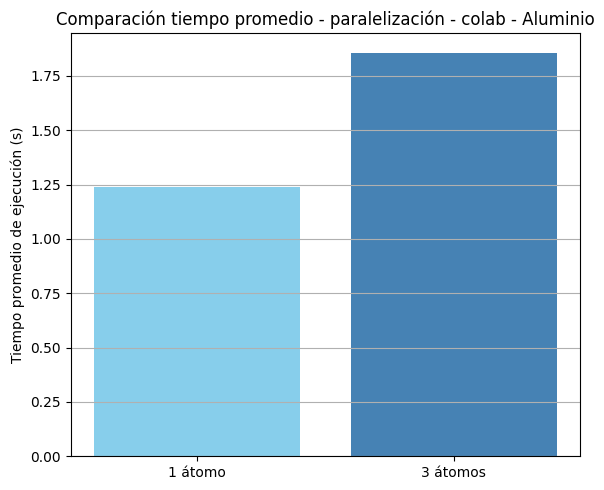

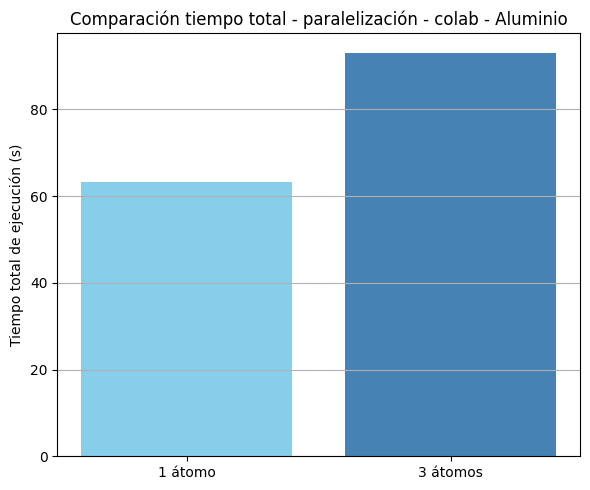

In [21]:
# Análisis para los tiempos
plt.figure(figsize=(10, 6))

# Graficar barras usando los valores del DataFrame
for i, (metal, tiempo, color) in enumerate(zip(resultados_tiempos_1atomo_par["Metales"], resultados_tiempos_1atomo_par["Tiempo promedio (s)"], colores)):
    plt.bar(metal, tiempo, color=color, label=metal)

plt.xlabel("Metales")
plt.ylabel("Tiempo de ejecución promedio (s)")
plt.title("Tiempo promedio - 1 átomo - paralelizacion - Colab")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis para los tiempos
plt.figure(figsize=(10, 6))

# Graficar barras usando los valores del DataFrame
for i, (metal, tiempo, color) in enumerate(zip(resultados_tiempos_1atomo_par["Metales"], resultados_tiempos_1atomo_par["Tiempo total (s)"], colores)):
    plt.bar(metal, tiempo, color=color, label=metal)

plt.xlabel("Metales")
plt.ylabel("Tiempo de ejecución total (s)")
plt.title("Tiempo total - 1 átomo - paralelizacion - Colab")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de comparación
plt.figure(figsize=(6, 5))
values = [resultados_tiempos_1atomo_par.loc[resultados_tiempos_1atomo_par["Metales"] == "Aluminio", "Tiempo promedio (s)"].values[0], resultados_tiempos_3atomos_par.loc[resultados_tiempos_3atomos_par["Metales"] == "Aluminio", "Tiempo promedio (s)"].values[0]]
plt.bar(["1 átomo", "3 átomos"], values, color=["skyblue", "steelblue"])
plt.ylabel("Tiempo promedio de ejecución (s)")
plt.title("Comparación tiempo promedio - paralelización - colab - Aluminio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Gráfico de comparación
plt.figure(figsize=(6, 5))
values = [resultados_tiempos_1atomo_par.loc[resultados_tiempos_1atomo_par["Metales"] == "Aluminio", "Tiempo total (s)"].values[0], resultados_tiempos_3atomos_par.loc[resultados_tiempos_3atomos_par["Metales"] == "Aluminio", "Tiempo total (s)"].values[0]]
plt.bar(["1 átomo", "3 átomos"], values, color=["skyblue", "steelblue"])
plt.ylabel("Tiempo total de ejecución (s)")
plt.title("Comparación tiempo total - paralelización - colab - Aluminio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

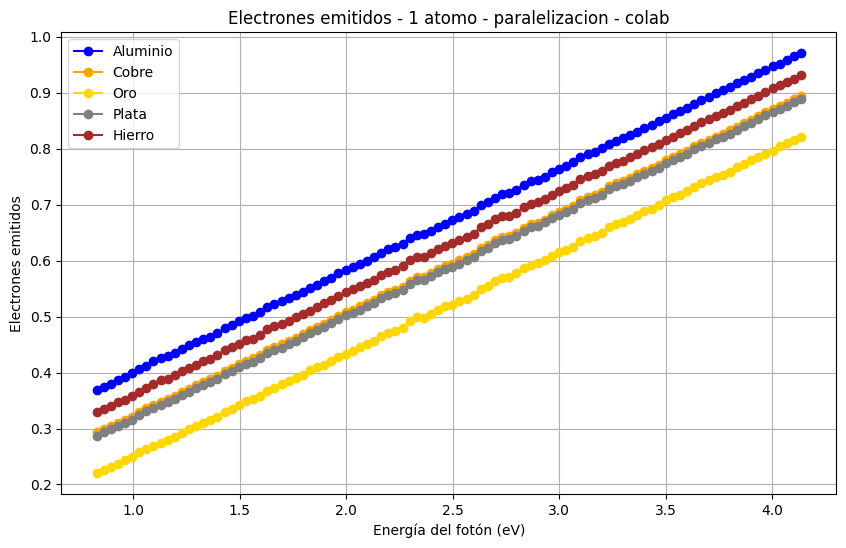

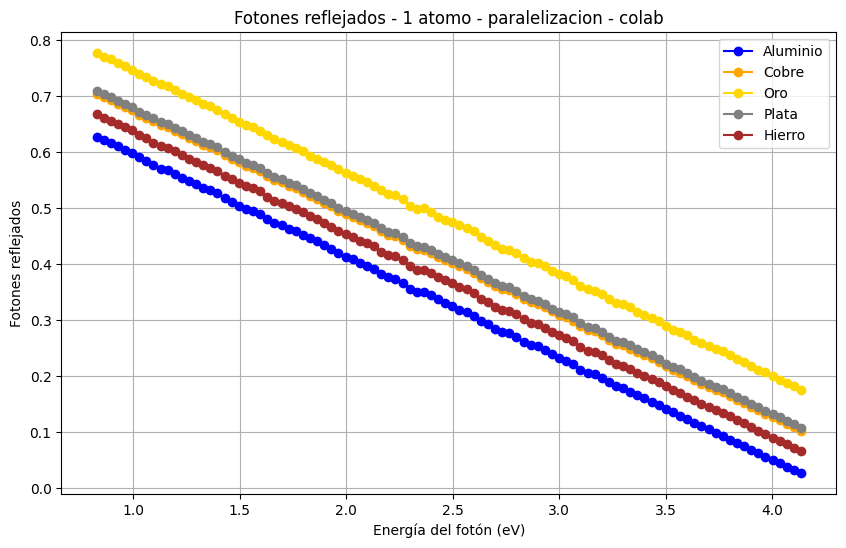

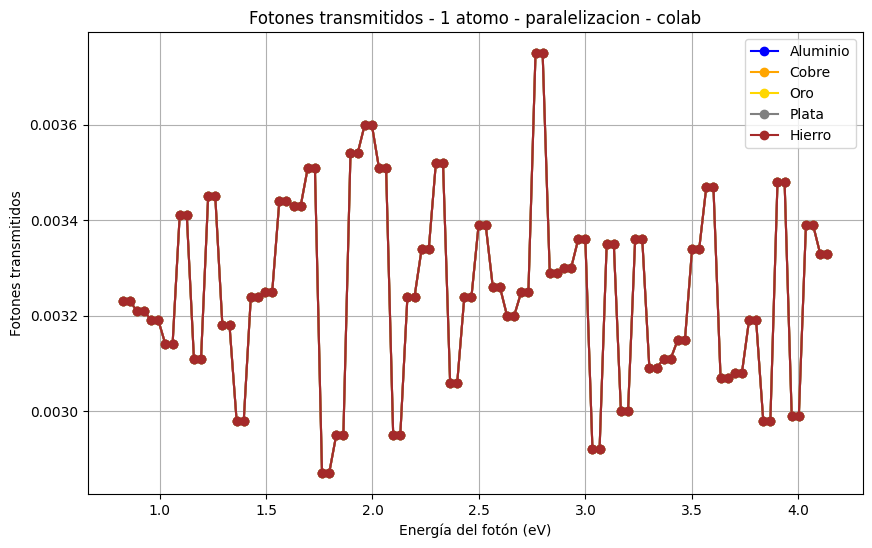

In [22]:
# graficas para el analisis de 1 solo atomo

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_par, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["electrones_emitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Electrones emitidos")
plt.title("Electrones emitidos - 1 atomo - paralelizacion - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_par, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_reflejados"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones reflejados")
plt.title("Fotones reflejados - 1 atomo - paralelizacion - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

for df, nombre, color in zip(resultados_1atomo_par, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_transmitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones transmitidos")
plt.title("Fotones transmitidos - 1 atomo - paralelizacion - colab")
plt.legend()
plt.grid(True)
plt.show()

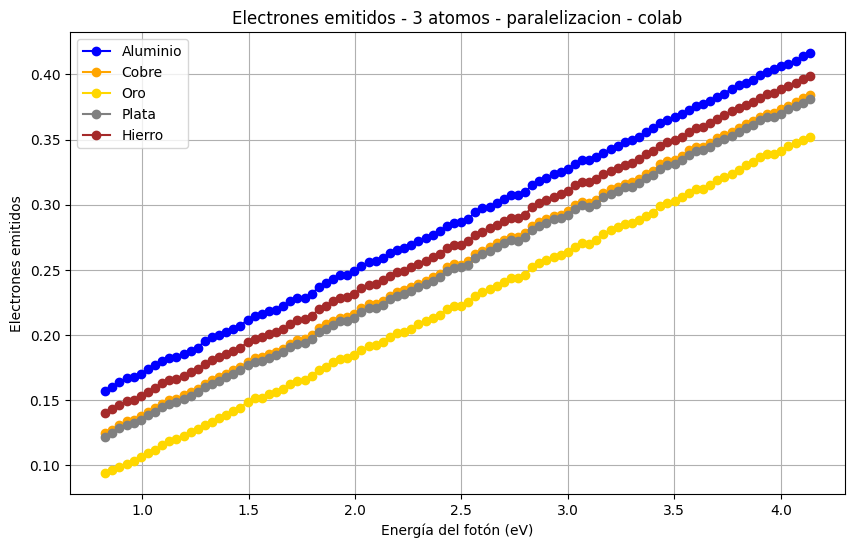

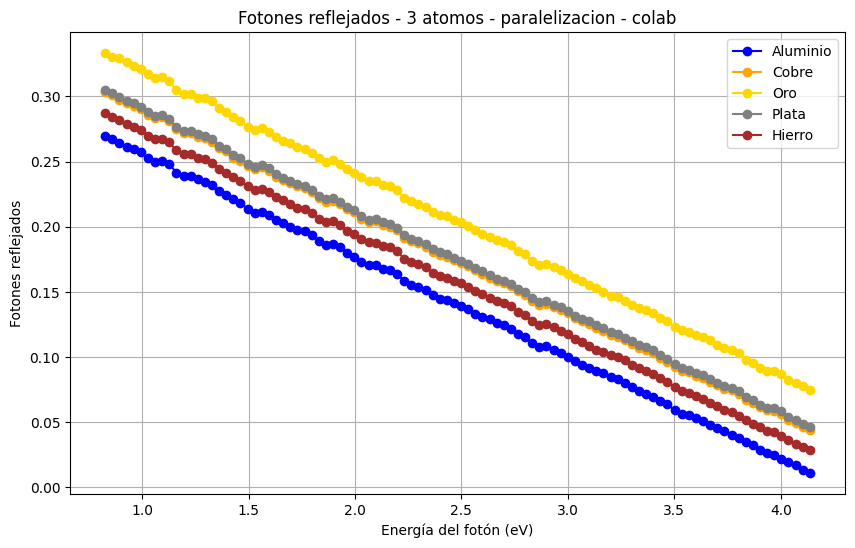

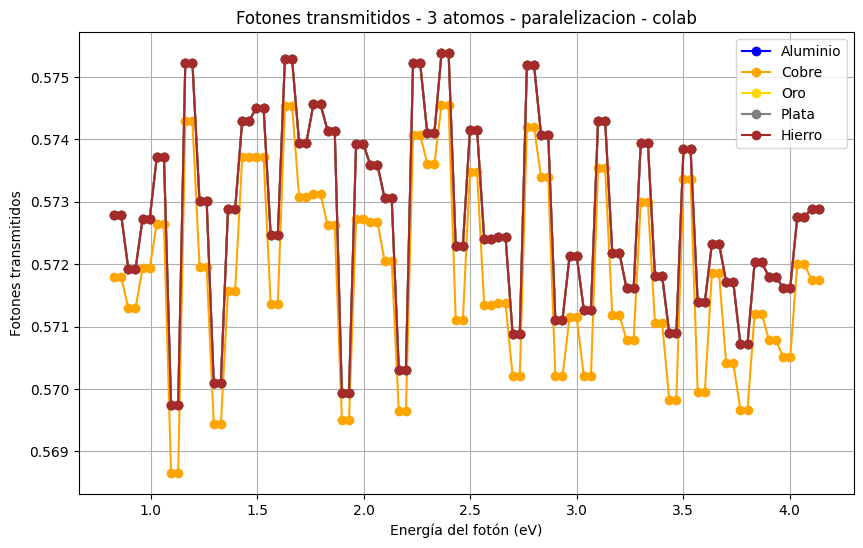

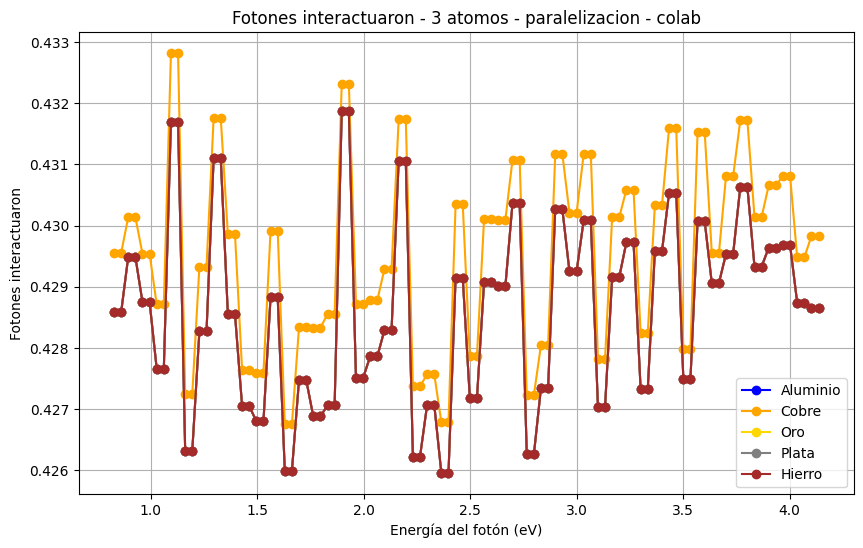

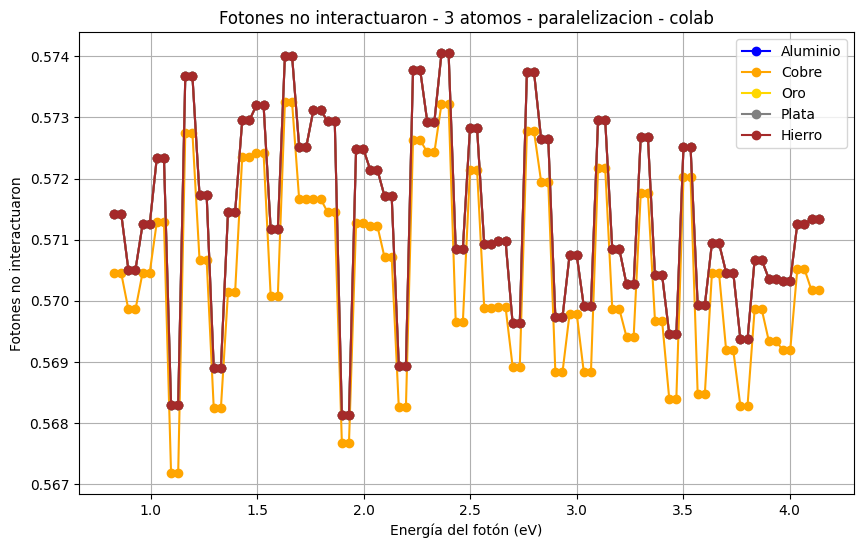

In [23]:
# graficas para el analisis de 3 solo atomo

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_par, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["electrones_emitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Electrones emitidos")
plt.title("Electrones emitidos - 3 atomos - paralelizacion - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_par, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_reflejados"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones reflejados")
plt.title("Fotones reflejados - 3 atomos - paralelizacion - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

for df, nombre, color in zip(resultados_3atomos_par, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_transmitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones transmitidos")
plt.title("Fotones transmitidos - 3 atomos - paralelizacion - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_par, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_interactuaron"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones interactuaron")
plt.title("Fotones interactuaron - 3 atomos - paralelizacion - colab")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_par, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_no_interactuaron"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones no interactuaron")
plt.title("Fotones no interactuaron - 3 atomos - paralelizacion - colab")
plt.legend()
plt.grid(True)
plt.show()

Análisis servidor en serie

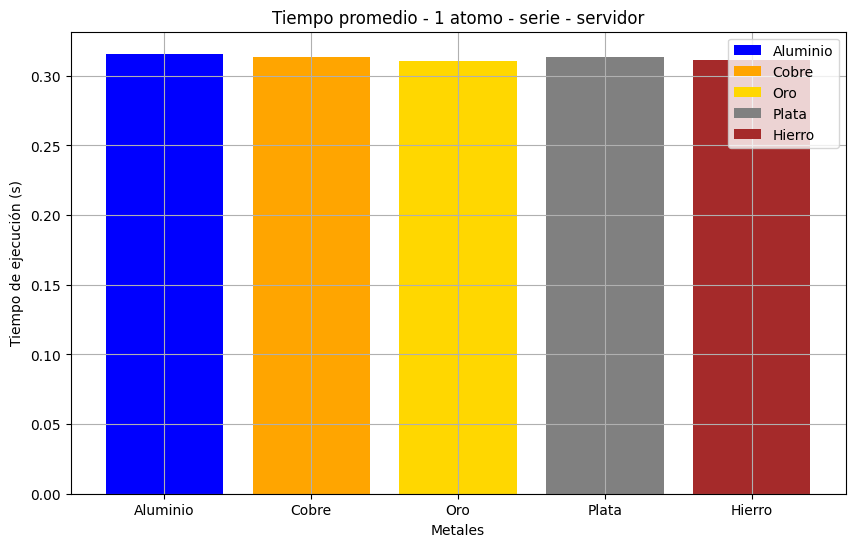

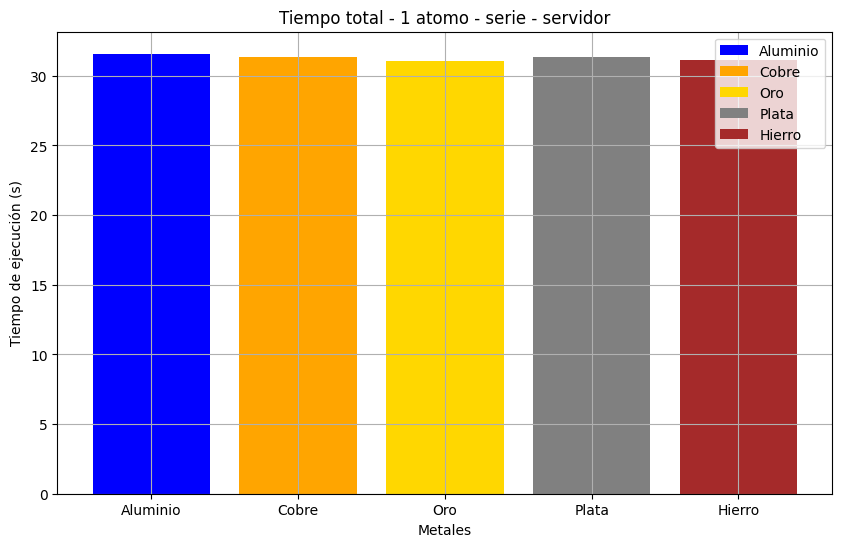

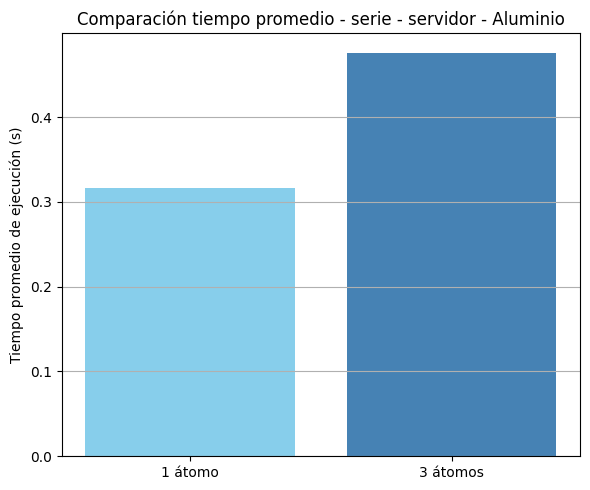

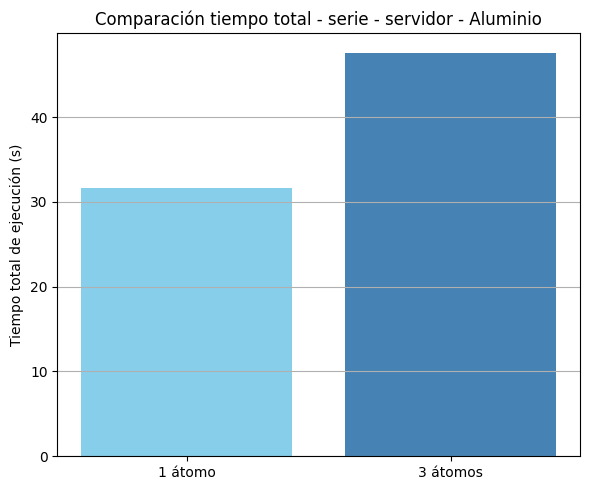

In [24]:
# Análisis para los tiempos
plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_servidor, Metales, colores):
    plt.bar(nombre, df["tiempo_ejecucion (s)"].mean(), label=nombre, color=color)

plt.xlabel("Metales")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo promedio - 1 atomo - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

# Análisis para los tiempos
plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_servidor, Metales, colores):
    plt.bar(nombre, df["tiempo_ejecucion (s)"].sum(), label=nombre, color=color)

plt.xlabel("Metales")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo total - 1 atomo - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de comparación
plt.figure(figsize=(6, 5))
plt.bar(["1 átomo", "3 átomos"], [resultados_1atomo_servidor[0]["tiempo_ejecucion (s)"].mean(), resultados_3atomos_servidor[0]["tiempo_ejecucion (s)"].mean()], color=["skyblue", "steelblue"])
plt.ylabel("Tiempo promedio de ejecución (s)")
plt.title("Comparación tiempo promedio - serie - servidor - Aluminio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Gráfico de comparación
plt.figure(figsize=(6, 5))
plt.bar(["1 átomo", "3 átomos"], [resultados_1atomo_servidor[0]["tiempo_ejecucion (s)"].sum(), resultados_3atomos_servidor[0]["tiempo_ejecucion (s)"].sum()], color=["skyblue", "steelblue"])
plt.ylabel("Tiempo total de ejecución (s)")
plt.title("Comparación tiempo total - serie - servidor - Aluminio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

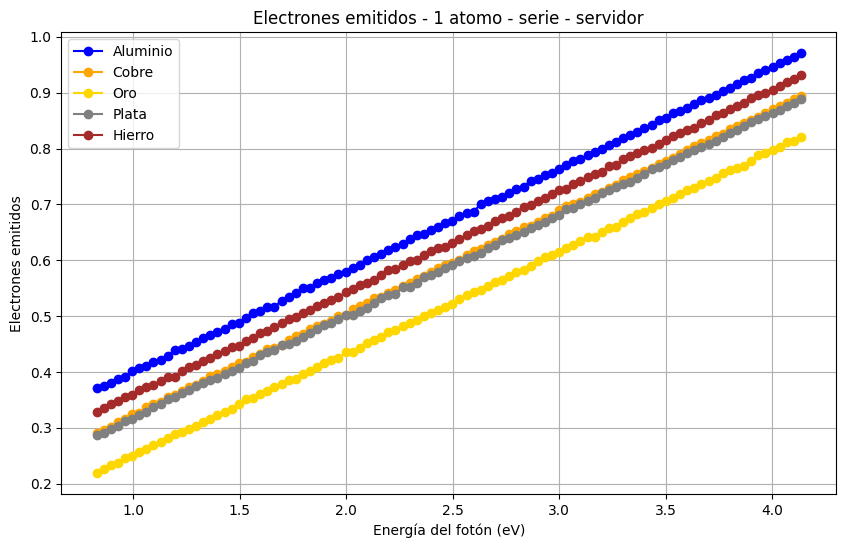

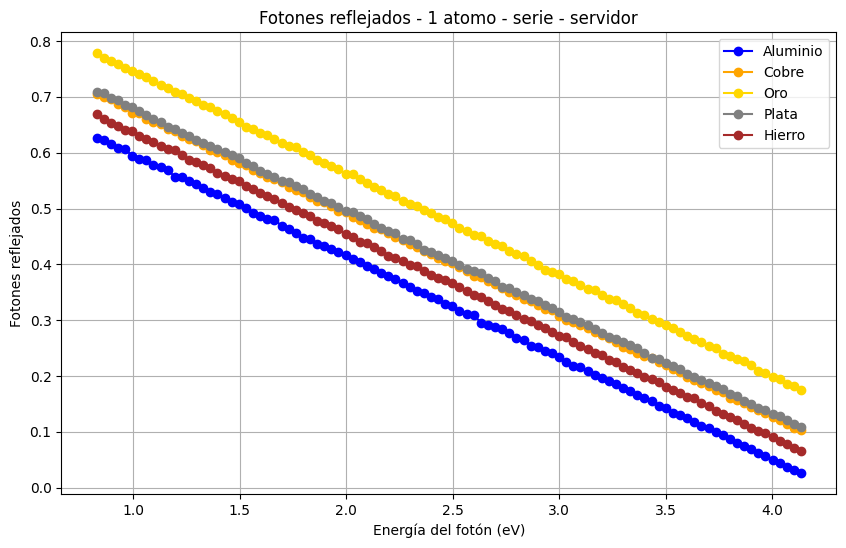

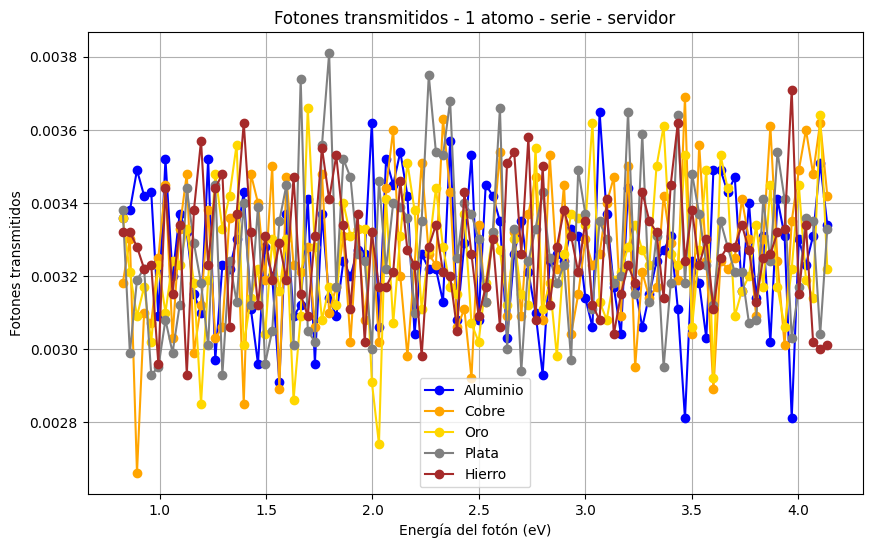

In [25]:
# graficas para el analisis de 1 solo atomo

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["electrones_emitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Electrones emitidos")
plt.title("Electrones emitidos - 1 atomo - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_reflejados"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones reflejados")
plt.title("Fotones reflejados - 1 atomo - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_transmitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones transmitidos")
plt.title("Fotones transmitidos - 1 atomo - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

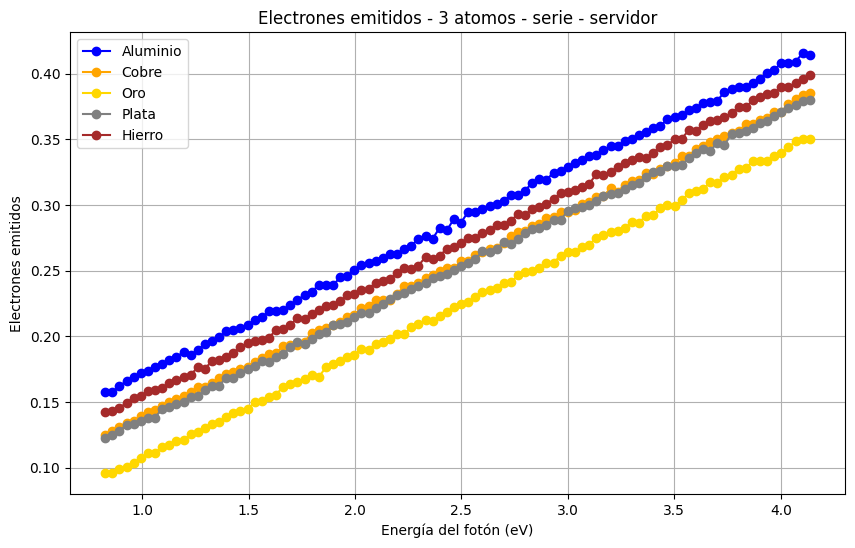

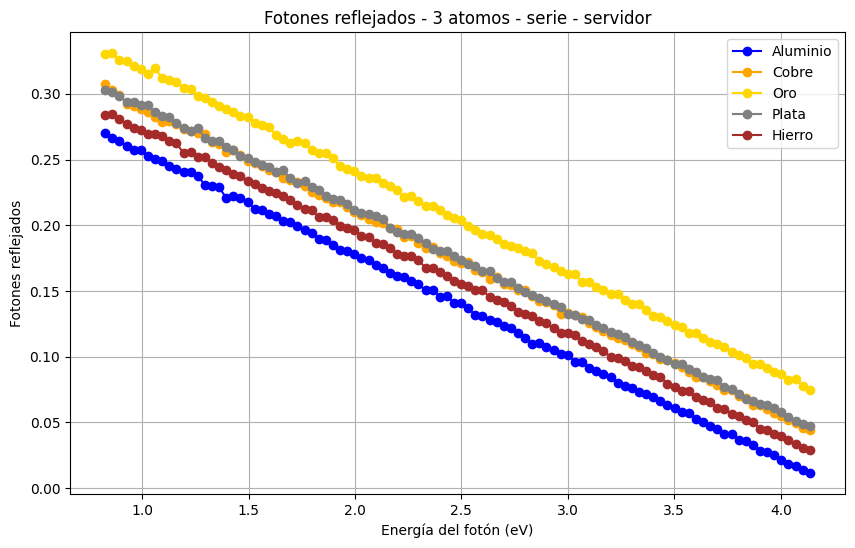

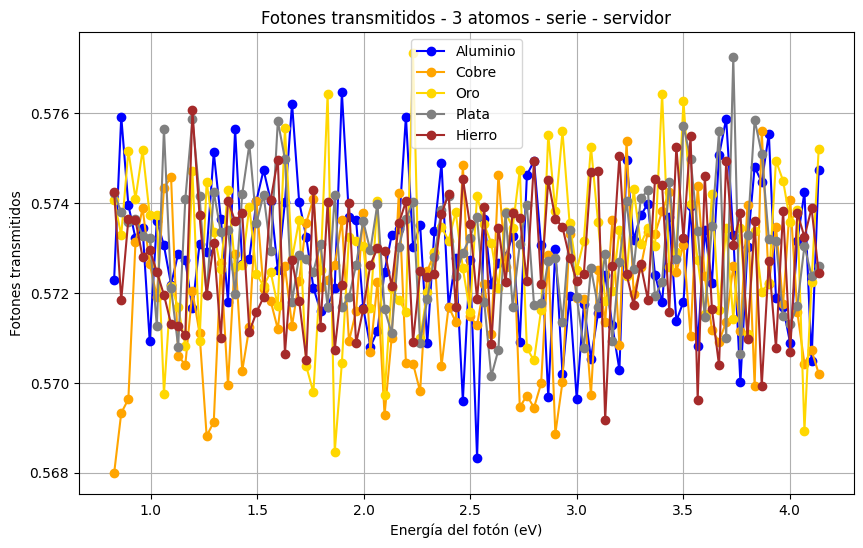

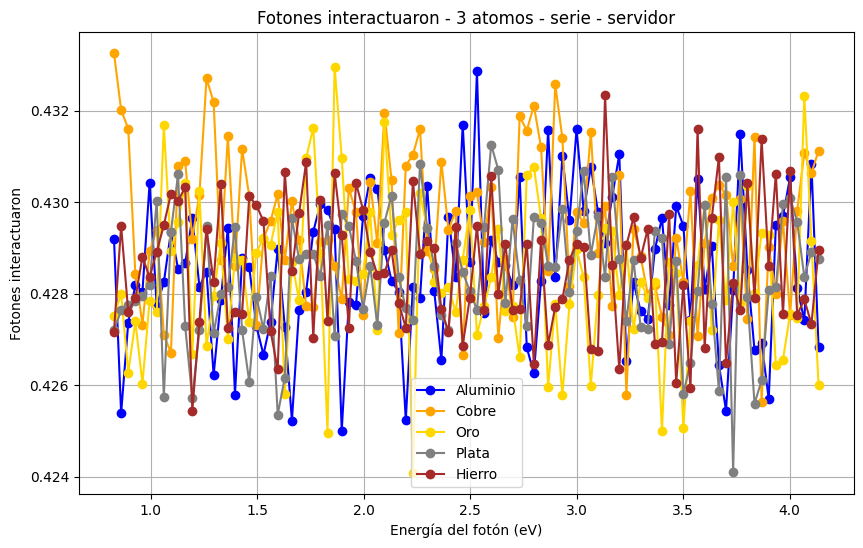

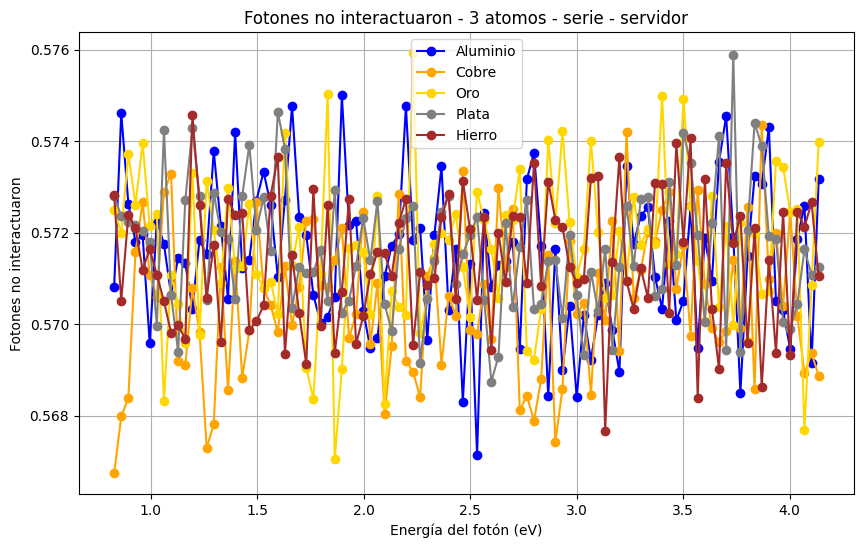

In [26]:
# graficas para los resultados de 3 atomos
plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["electrones_emitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Electrones emitidos")
plt.title("Electrones emitidos - 3 atomos - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_reflejados"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones reflejados")
plt.title("Fotones reflejados - 3 atomos - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_transmitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones transmitidos")
plt.title("Fotones transmitidos - 3 atomos - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_interactuaron"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones interactuaron")
plt.title("Fotones interactuaron - 3 atomos - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_no_interactuaron"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones no interactuaron")
plt.title("Fotones no interactuaron - 3 atomos - serie - servidor")
plt.legend()
plt.grid(True)
plt.show()

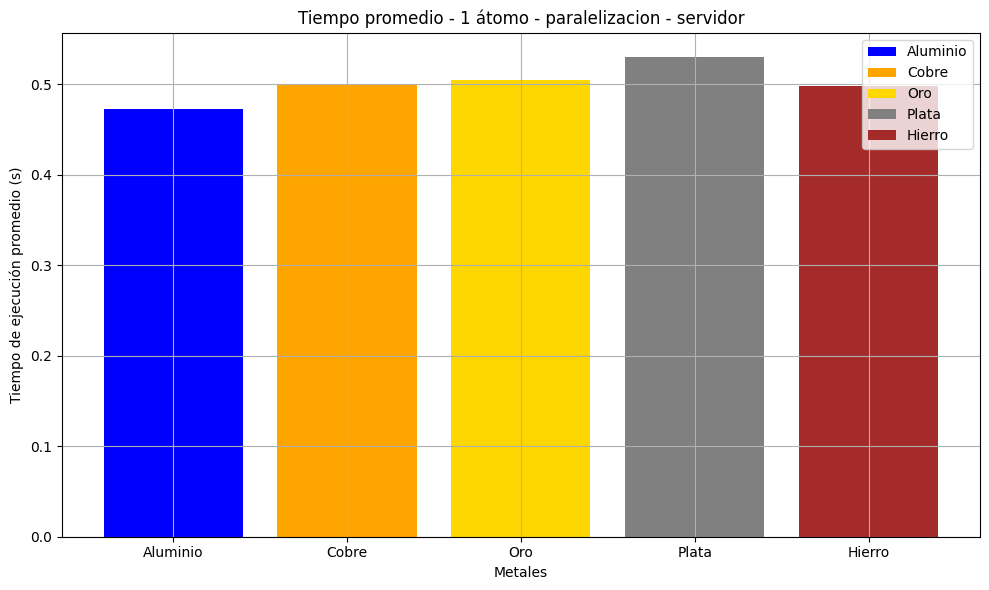

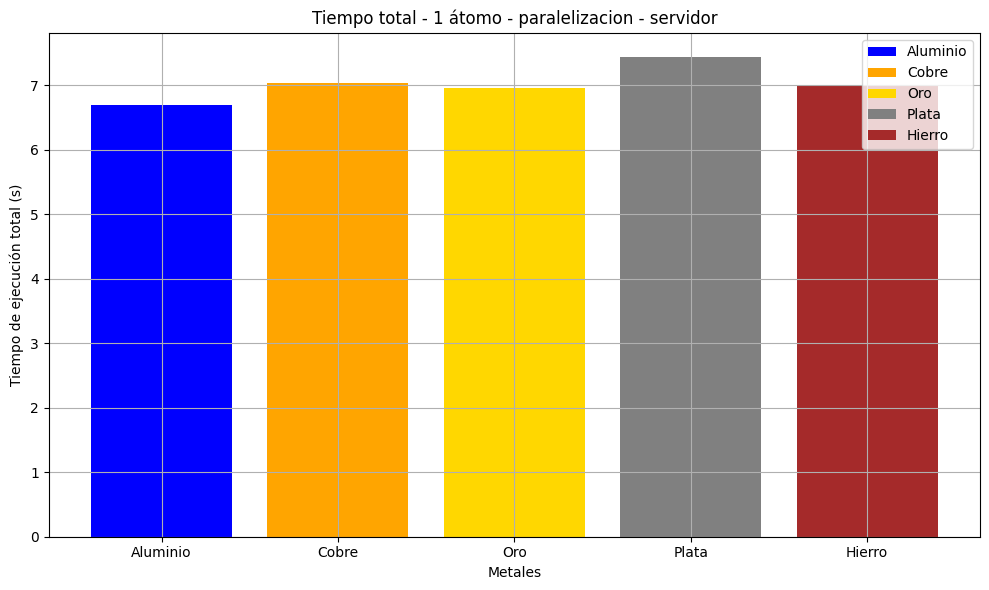

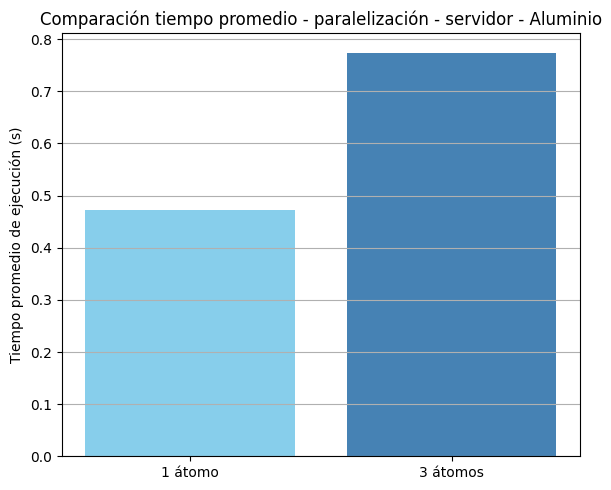

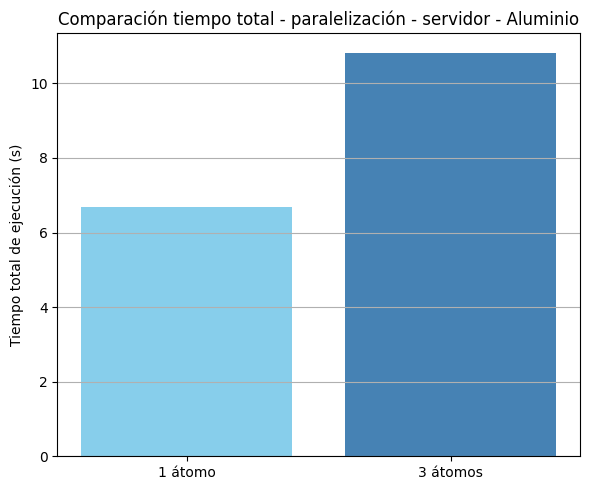

In [27]:
# Análisis para los tiempos
plt.figure(figsize=(10, 6))

# Graficar barras usando los valores del DataFrame
for i, (metal, tiempo, color) in enumerate(zip(resultados_tiempos_1atomo_par_servidor["Metales"], resultados_tiempos_1atomo_par_servidor["Tiempo promedio (s)"], colores)):
    plt.bar(metal, tiempo, color=color, label=metal)

plt.xlabel("Metales")
plt.ylabel("Tiempo de ejecución promedio (s)")
plt.title("Tiempo promedio - 1 átomo - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis para los tiempos
plt.figure(figsize=(10, 6))

# Graficar barras usando los valores del DataFrame
for i, (metal, tiempo, color) in enumerate(zip(resultados_tiempos_1atomo_par_servidor["Metales"], resultados_tiempos_1atomo_par_servidor["Tiempo total (s)"], colores)):
    plt.bar(metal, tiempo, color=color, label=metal)

plt.xlabel("Metales")
plt.ylabel("Tiempo de ejecución total (s)")
plt.title("Tiempo total - 1 átomo - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de comparación
plt.figure(figsize=(6, 5))
values = [resultados_tiempos_1atomo_par_servidor.loc[resultados_tiempos_1atomo_par_servidor["Metales"] == "Aluminio", "Tiempo promedio (s)"].values[0], resultados_tiempos_3atomos_par_servidor.loc[resultados_tiempos_3atomos_par_servidor["Metales"] == "Aluminio", "Tiempo promedio (s)"].values[0]]
plt.bar(["1 átomo", "3 átomos"], values, color=["skyblue", "steelblue"])
plt.ylabel("Tiempo promedio de ejecución (s)")
plt.title("Comparación tiempo promedio - paralelización - servidor - Aluminio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Gráfico de comparación
plt.figure(figsize=(6, 5))
values = [resultados_tiempos_1atomo_par_servidor.loc[resultados_tiempos_1atomo_par_servidor["Metales"] == "Aluminio", "Tiempo total (s)"].values[0], resultados_tiempos_3atomos_par_servidor.loc[resultados_tiempos_3atomos_par_servidor["Metales"] == "Aluminio", "Tiempo total (s)"].values[0]]
plt.bar(["1 átomo", "3 átomos"], values, color=["skyblue", "steelblue"])
plt.ylabel("Tiempo total de ejecución (s)")
plt.title("Comparación tiempo total - paralelización - servidor - Aluminio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

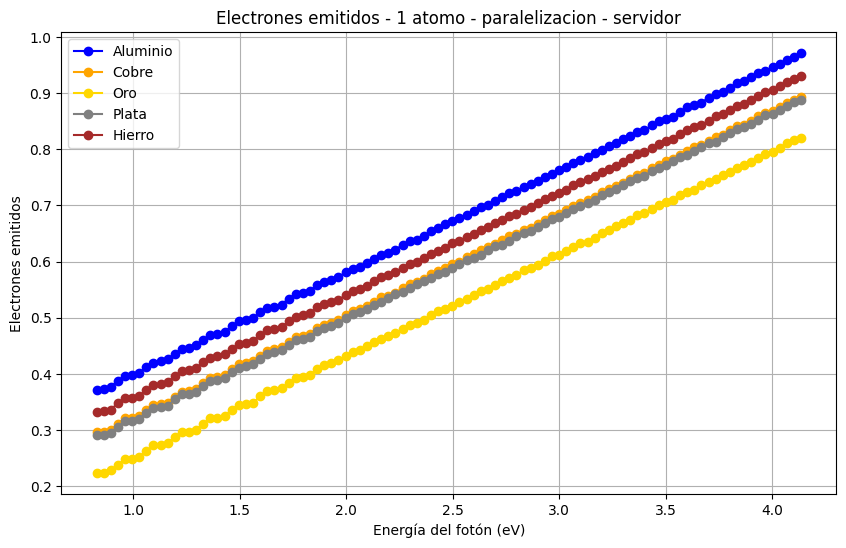

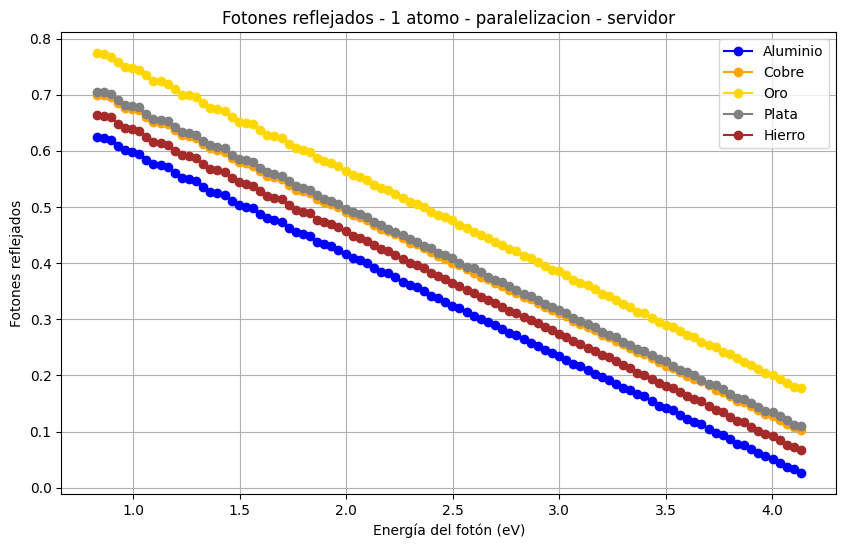

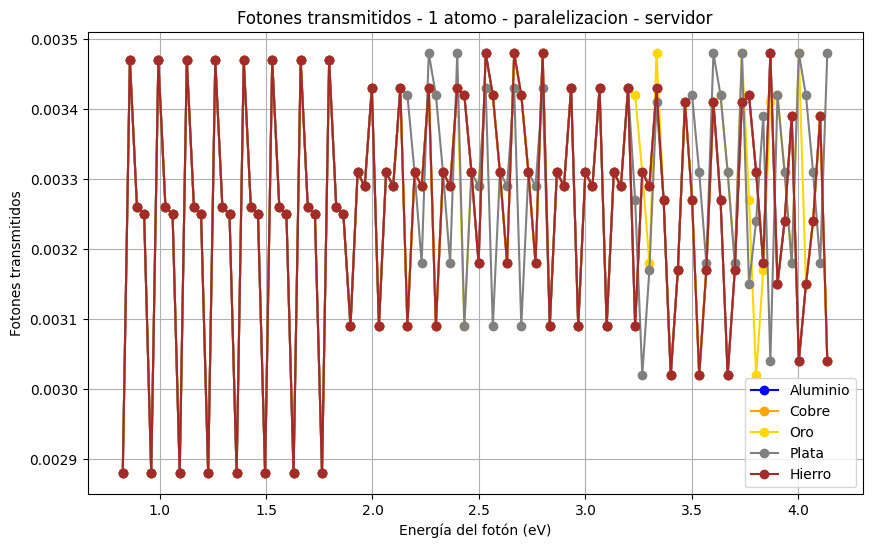

In [28]:
# graficas para el analisis de 1 solo atomo

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_par_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["electrones_emitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Electrones emitidos")
plt.title("Electrones emitidos - 1 atomo - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_1atomo_par_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_reflejados"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones reflejados")
plt.title("Fotones reflejados - 1 atomo - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

for df, nombre, color in zip(resultados_1atomo_par_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_transmitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones transmitidos")
plt.title("Fotones transmitidos - 1 atomo - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.show()

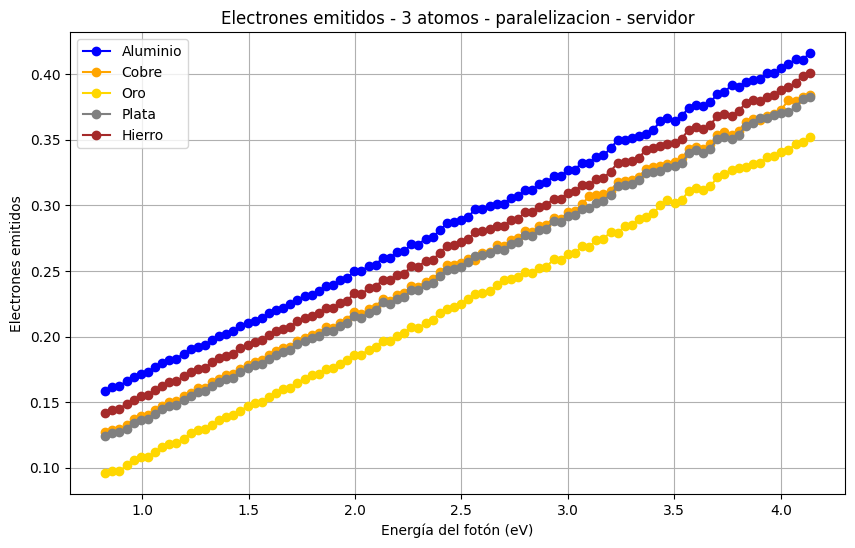

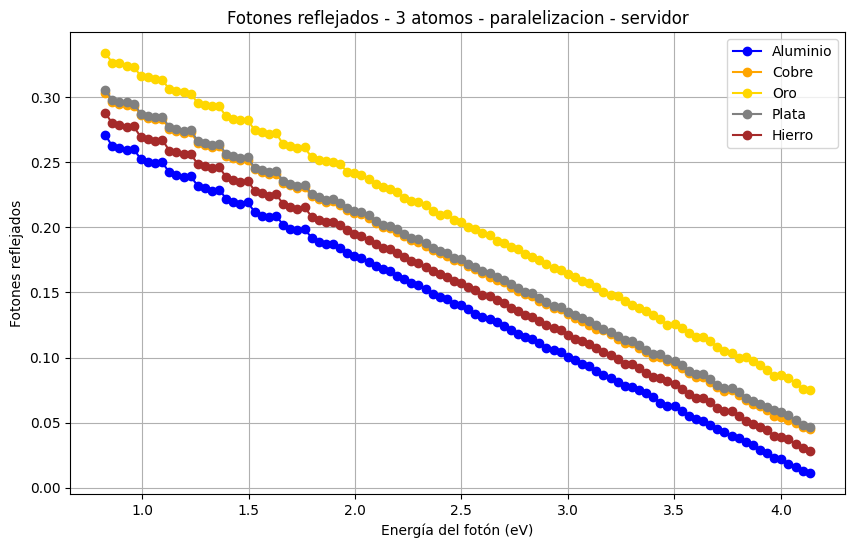

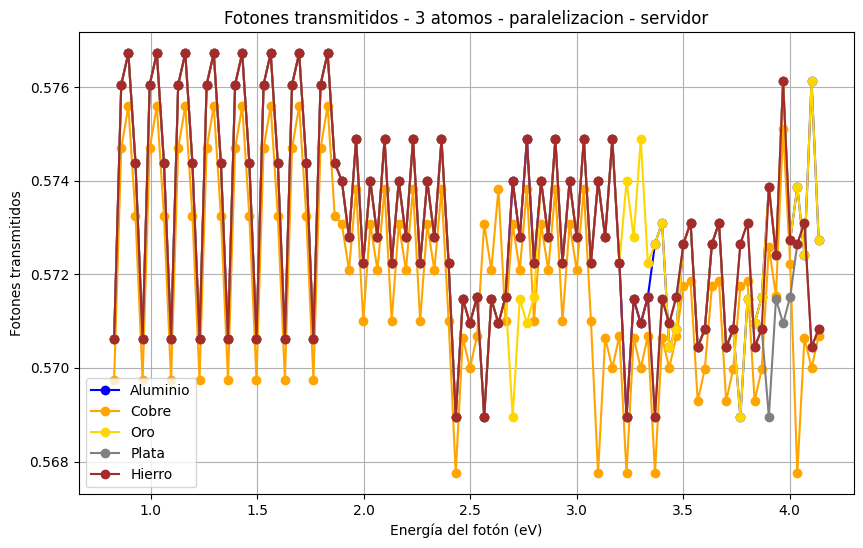

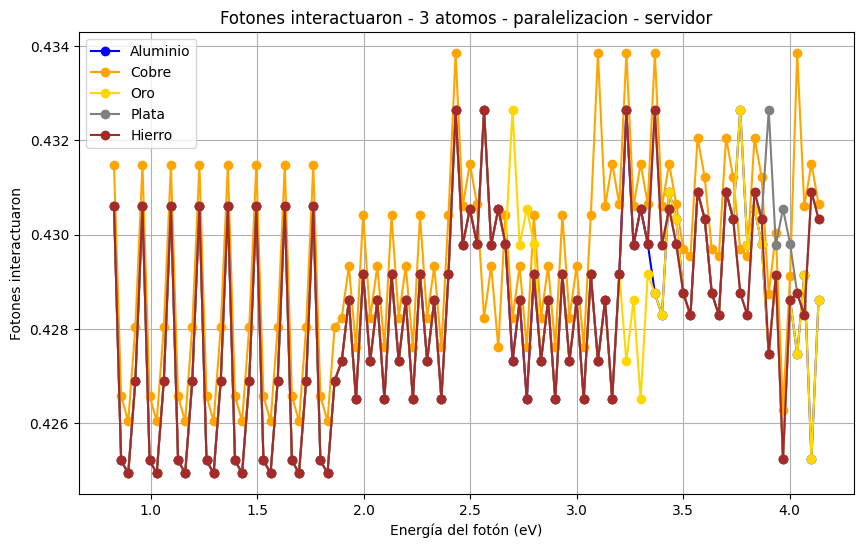

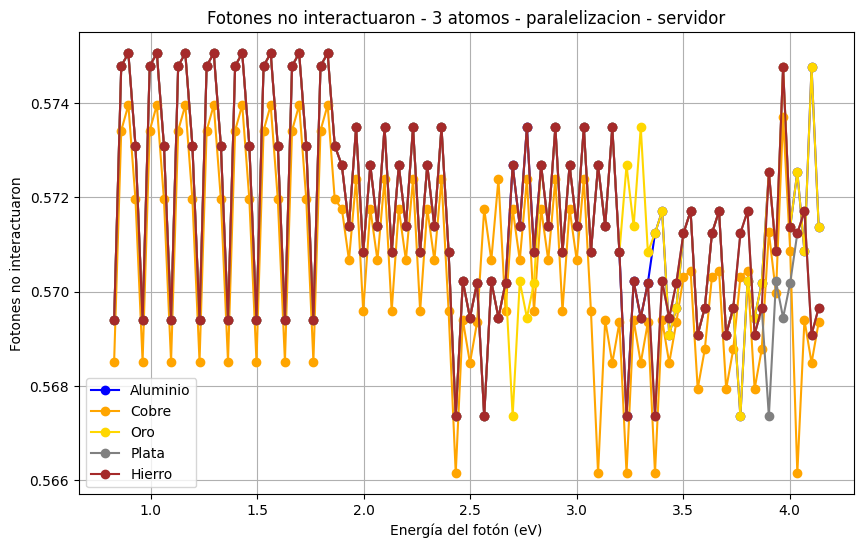

In [29]:
# graficas para el analisis de 3 solo atomo

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_par_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["electrones_emitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Electrones emitidos")
plt.title("Electrones emitidos - 3 atomos - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_par_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_reflejados"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones reflejados")
plt.title("Fotones reflejados - 3 atomos - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

for df, nombre, color in zip(resultados_3atomos_par_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_transmitidos"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones transmitidos")
plt.title("Fotones transmitidos - 3 atomos - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_par_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_interactuaron"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones interactuaron")
plt.title("Fotones interactuaron - 3 atomos - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for df, nombre, color in zip(resultados_3atomos_par_servidor, Metales, colores):
    plt.plot(df["energia_foton (eV)"], df["fotones_no_interactuaron"], marker='o', linestyle='-', label=nombre, color=color)

plt.xlabel("Energía del fotón (eV)")
plt.ylabel("Fotones no interactuaron")
plt.title("Fotones no interactuaron - 3 atomos - paralelizacion - servidor")
plt.legend()
plt.grid(True)
plt.show()